In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib



In [26]:
data = pd.read_csv("BakuApartmentData.Csv")
data.info()
print(data.columns)
print(data.describe().round(2))
print("NaN count:", data.isna().sum().sum())
print("Duplicates count:", data.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39302 entries, 0 to 39301
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        39302 non-null  int64  
 1   price             39302 non-null  int64  
 2   location          39302 non-null  object 
 3   rooms             39302 non-null  int64  
 4   square            39302 non-null  float64
 5   floor             39302 non-null  object 
 6   new_building      39302 non-null  int64  
 7   has_repair        39302 non-null  int64  
 8   has_bill_of_sale  39302 non-null  int64  
 9   has_mortgage      39302 non-null  int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 3.0+ MB
Index(['Unnamed: 0', 'price', 'location', 'rooms', 'square', 'floor',
       'new_building', 'has_repair', 'has_bill_of_sale', 'has_mortgage'],
      dtype='object')
       Unnamed: 0       price     rooms    square  new_building  has_repair  \
count    39302.00   

In [27]:
# NaN-ları sil
data.dropna(inplace=True)
# Duplicates-ları sil
data.drop_duplicates(inplace=True)


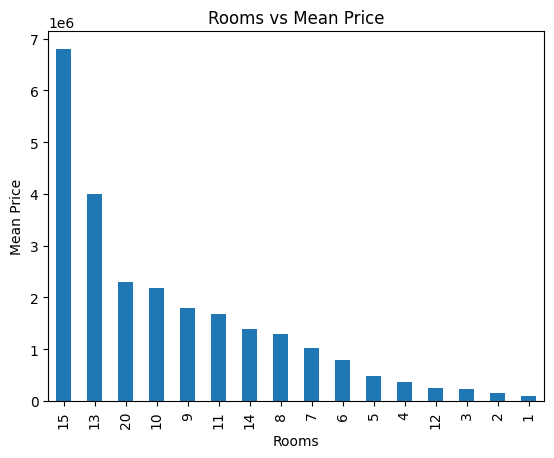

In [28]:
data.groupby("rooms")["price"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Rooms vs Mean Price")
plt.ylabel("Mean Price")
plt.xlabel("Rooms")
plt.show()


In [29]:
X = data[['square', 'floor', 'rooms', 'new_building', 'has_repair', 'location']].copy()
y = data['price'].copy()


In [30]:
def convert_fraction(x):
    if isinstance(x, str) and "/" in x:
        a, b = x.split("/")
        return float(a)/float(b)
    return x
X['floor'] = X['floor'].apply(convert_fraction).astype(int)
X = pd.get_dummies(X, columns=['location'], drop_first=True)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [32]:
tree_model = DecisionTreeRegressor(random_state=42)
param_grid_tree = {
    "criterion": ["squared_error", "friedman_mse"],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_tree = GridSearchCV(tree_model, param_grid=param_grid_tree, cv=5,scoring='neg_mean_squared_error', n_jobs=-1)

grid_tree.fit(X_train, y_train)

print("Best DecisionTree Params:", grid_tree.best_params_)

tree_preds = grid_tree.predict(X_test)
print("DecisionTree MSE:", mean_squared_error(y_test, tree_preds))


Best DecisionTree Params: {'criterion': 'friedman_mse', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2}
DecisionTree MSE: 14690487639.757


In [33]:
lr = LinearRegression()
lr.fit(X_train, y_train)

preds_lr = lr.predict(X_test)
print("Linear Regression MSE:", mean_squared_error(y_test, preds_lr))


Linear Regression MSE: 9514413169.139252


In [34]:
rfr_model = RandomForestRegressor(random_state=42)

param_grid_rfr = {
    "max_depth": [5, 10, 15],
    "n_estimators": [5, 10, 20]
}

grid_rfr = GridSearchCV(rfr_model, param_grid=param_grid_rfr, cv=5,
                        scoring='neg_mean_absolute_error', n_jobs=-1)

grid_rfr.fit(X_train, y_train)

print("Best RandomForest Params:", grid_rfr.best_params_)

rfr_preds = grid_rfr.predict(X_test)
print("RandomForest MAE:", mean_absolute_error(y_test, rfr_preds))


Best RandomForest Params: {'max_depth': 15, 'n_estimators': 20}
RandomForest MAE: 38631.73639045281


In [35]:
# RandomForest modelini saxlamaq
joblib.dump(grid_rfr, "model.pkl")

# Feature-lar
print("Feature columns:", X.columns)


Feature columns: Index(['square', 'floor', 'rooms', 'new_building', 'has_repair',
       'location_20 Yanvar m.', 'location_20-ci sahə q.', 'location_28 May m.',
       'location_28 May q.', 'location_3-cü mikrorayon q.',
       ...
       'location_Çiçək q.', 'location_İnşaatçılar m.',
       'location_İçəri Şəhər m.', 'location_Şah İsmayıl Xətai m.',
       'location_Şimal DRES q.', 'location_Şıxov q.', 'location_Əhmədli m.',
       'location_Əhmədli q.', 'location_Ələt q.', 'location_Əmircan q.'],
      dtype='object', length=115)


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39302 entries, 0 to 39301
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        39302 non-null  int64  
 1   price             39302 non-null  int64  
 2   location          39302 non-null  object 
 3   rooms             39302 non-null  int64  
 4   square            39302 non-null  float64
 5   floor             39302 non-null  object 
 6   new_building      39302 non-null  int64  
 7   has_repair        39302 non-null  int64  
 8   has_bill_of_sale  39302 non-null  int64  
 9   has_mortgage      39302 non-null  int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 3.0+ MB
